   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006

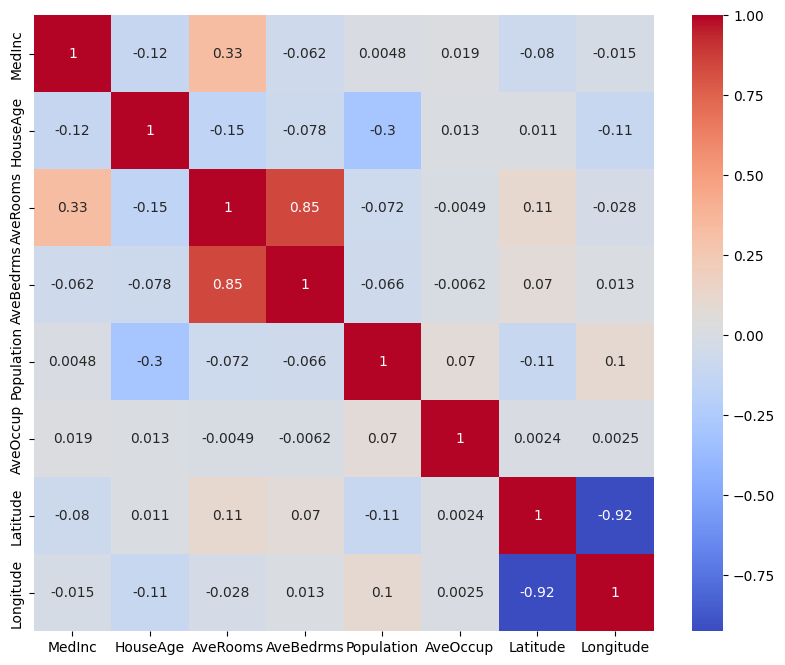

LinearRegression: MSE=0.556, RMSE=0.746, MAE=0.533, R2=0.576
Ridge: MSE=0.556, RMSE=0.746, MAE=0.533, R2=0.576
Lasso: MSE=0.680, RMSE=0.824, MAE=0.622, R2=0.481
LinearRegression (train): MSE=0.518, RMSE=0.720, MAE=0.529, R2=0.613


/Users/roman/HomeWorkSeverynRoman/hw04_/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/HomeWorkSeverynRoman/hw04_/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/HomeWorkSeverynRoman/hw04_/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/roman/HomeWorkSeverynRoman/hw04_/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/roman/HomeWorkSeverynRoman/hw04_/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/roman/HomeWorkSeverynRoman/hw04_/.venv/lib/python3.9/site-packages/

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Загрузка данных (пример с California housing)
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

# 2. EDA
print(X.head())
print(X.describe())
print(X.isnull().sum())  # нет пропусков
# Корреляция с целевой переменной
corr_with_target = X.corrwith(pd.Series(y))
print(corr_with_target)
# Тепловая карта корреляций между признаками
plt.figure(figsize=(10,8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm')
plt.show()

# 3. Предобработка: масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# 5. Обучение линейной регрессии
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# 6. Ridge с подбором alpha
ridge = Ridge()
params = {'alpha': [0.1, 1.0, 10.0, 100.0]}
ridge_cv = GridSearchCV(ridge, params, cv=5, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train, y_train)
best_ridge = ridge_cv.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)

# 7. Lasso
lasso = Lasso(max_iter=10000)
lasso_cv = GridSearchCV(lasso, params, cv=5)
lasso_cv.fit(X_train, y_train)
best_lasso = lasso_cv.best_estimator_
y_pred_lasso = best_lasso.predict(X_test)

# 8. Метрики
def print_metrics(name, y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name}: MSE={mse:.3f}, RMSE={rmse:.3f}, MAE={mae:.3f}, R2={r2:.3f}")

print_metrics("LinearRegression", y_test, y_pred_lr)
print_metrics("Ridge", y_test, y_pred_ridge)
print_metrics("Lasso", y_test, y_pred_lasso)

# 9. Проверка переобучения
train_pred_lr = lr.predict(X_train)
print_metrics("LinearRegression (train)", y_train, train_pred_lr)
# Если метрики на трейне намного лучше, чем на тесте – переобучение.